CLEANING.

In [1]:
import pandas as pd

df = pd.read_csv('adult.data')
df.columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 
              'marital-status', 'occupation', 'relationship', 'race', 'sex', 
              'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']
print(df.head())
print(df.shape)


   age          workclass  fnlwgt   education  education-num  \
0   50   Self-emp-not-inc   83311   Bachelors             13   
1   38            Private  215646     HS-grad              9   
2   53            Private  234721        11th              7   
3   28            Private  338409   Bachelors             13   
4   37            Private  284582     Masters             14   

        marital-status          occupation    relationship    race      sex  \
0   Married-civ-spouse     Exec-managerial         Husband   White     Male   
1             Divorced   Handlers-cleaners   Not-in-family   White     Male   
2   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
3   Married-civ-spouse      Prof-specialty            Wife   Black   Female   
4   Married-civ-spouse     Exec-managerial            Wife   White   Female   

   capital-gain  capital-loss  hours-per-week  native-country  income  
0             0             0              13   United-States   <=50

In [2]:
print(df.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


In [3]:
print(df['race'].value_counts())

race
White                 27815
Black                  3124
Asian-Pac-Islander     1039
Amer-Indian-Eskimo      311
Other                   271
Name: count, dtype: int64


In [4]:
print(df['sex'].value_counts())

sex
Male      21789
Female    10771
Name: count, dtype: int64


In [5]:
print(df['sex'].unique())

<StringArray>
[' Male', ' Female']
Length: 2, dtype: str


In [6]:
df['sex'] = df['sex'].str.strip()

In [7]:
df['sex'] = df['sex'].map({'Male': 0, 'Female': 1})

In [8]:
print(df['capital-gain'].value_counts())

capital-gain
0        29849
15024      347
7688       284
7298       246
99999      159
         ...  
6097         1
1639         1
7978         1
2387         1
5060         1
Name: count, Length: 119, dtype: int64


In [9]:
print(df['income'].value_counts())

income
<=50K    24719
>50K      7841
Name: count, dtype: int64


In [10]:
print(df['income'].unique())

<StringArray>
[' <=50K', ' >50K']
Length: 2, dtype: str


In [11]:
df['income'] = df['income'].str.strip()
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})

In [12]:
print(df.head())

   age          workclass  fnlwgt   education  education-num  \
0   50   Self-emp-not-inc   83311   Bachelors             13   
1   38            Private  215646     HS-grad              9   
2   53            Private  234721        11th              7   
3   28            Private  338409   Bachelors             13   
4   37            Private  284582     Masters             14   

        marital-status          occupation    relationship    race  sex  \
0   Married-civ-spouse     Exec-managerial         Husband   White    0   
1             Divorced   Handlers-cleaners   Not-in-family   White    0   
2   Married-civ-spouse   Handlers-cleaners         Husband   Black    0   
3   Married-civ-spouse      Prof-specialty            Wife   Black    1   
4   Married-civ-spouse     Exec-managerial            Wife   White    1   

   capital-gain  capital-loss  hours-per-week  native-country  income  
0             0             0              13   United-States       0  
1             0     

In [13]:
print(df['workclass'].value_counts())
print(df['occupation'].value_counts())

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1297
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64
occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3769
Sales                3650
Other-service        3295
Machine-op-inspct    2002
?                    1843
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64


In [14]:
import numpy as np

df = df.replace(' ?', np.nan)
print(df.isnull().sum())
print(df.shape)

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64
(32560, 15)


WE ARE NOW STRIPPING THE SPACES OF EVERY OBJECT  IN THE DATAFRAME.


In [15]:
df = df.apply(lambda x: x.str.strip() if x.dtype == 'object' else x)
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 32560 entries, 0 to 32559
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32560 non-null  int64
 1   workclass       30724 non-null  str  
 2   fnlwgt          32560 non-null  int64
 3   education       32560 non-null  str  
 4   education-num   32560 non-null  int64
 5   marital-status  32560 non-null  str  
 6   occupation      30717 non-null  str  
 7   relationship    32560 non-null  str  
 8   race            32560 non-null  str  
 9   sex             32560 non-null  int64
 10  capital-gain    32560 non-null  int64
 11  capital-loss    32560 non-null  int64
 12  hours-per-week  32560 non-null  int64
 13  native-country  31977 non-null  str  
 14  income          32560 non-null  int64
dtypes: int64(8), str(7)
memory usage: 3.7 MB
None


In [16]:
df_org = df.copy()

In [17]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['income'])
y = df['income']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [19]:
cols_with_nan = ['workclass' , 'occupation', 'native-country']

for col in cols_with_nan:
    mode_val = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode_val)
    X_test[col] = X_test[col].fillna(mode_val)

VISUALIZATION AFTER SPLITTING AND FILLING THE NULL DATA.

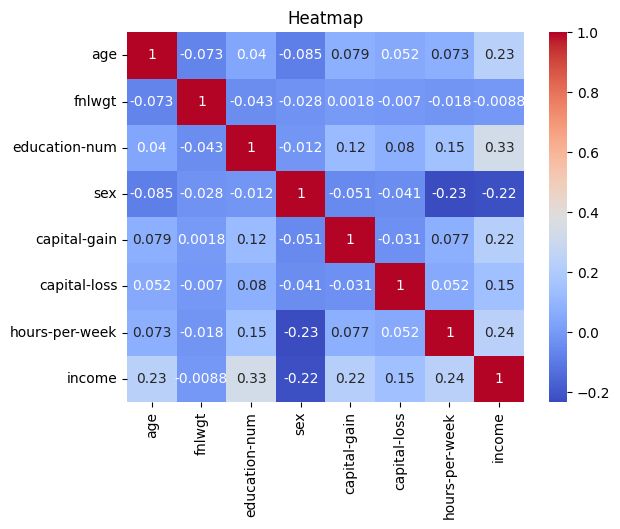

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

x_viz = pd.concat([X_train, y_train], axis = 1)

corr = x_viz.select_dtypes(include = 'number').corr()
sns.heatmap(corr,  annot = True, cmap = 'coolwarm')
plt.title('Heatmap')
plt.show()

Here, the most relevalnt one is education-num at 0.34, then age, and hours  per week, then sex and capital gain.

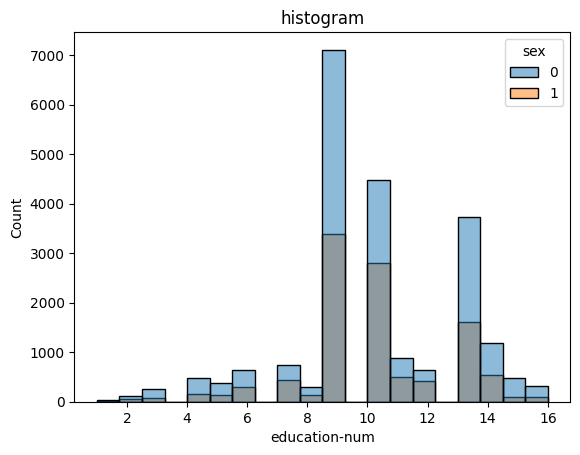

In [21]:
sns.histplot(data=df, x = 'education-num', hue = 'sex', bins = 20)
plt.title('histogram')
plt.show()

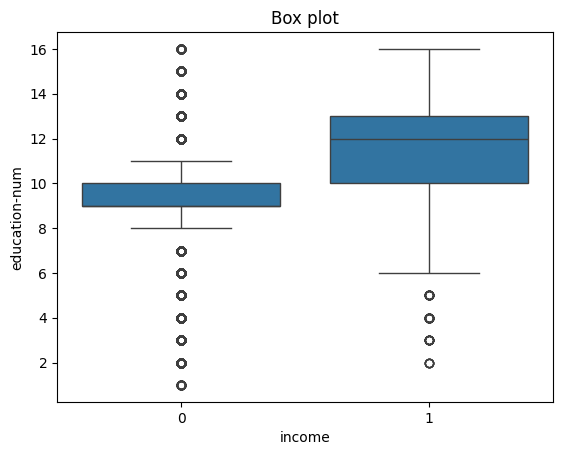

In [22]:
sns.boxplot(x = 'income', y = 'education-num', data = x_viz)
plt.title('Box plot')
plt.show()

NOW ONE HOT ENCODING.

In [23]:
X_train = pd.get_dummies(X_train, columns=['workclass', 'education', 'marital-status', 
                                            'occupation', 'relationship', 'race', 
                                            'native-country'], drop_first=True)

X_test = pd.get_dummies(X_test, columns=['workclass', 'education', 'marital-status', 
                                          'occupation', 'relationship', 'race', 
                                          'native-country'], drop_first=True)

In [24]:
print(X_train.shape)
print(X_test.shape)

(26048, 97)
(6512, 95)


DIFFERENT NO OF  COLUMNS SO WE DO THIS

In [25]:
X_train, X_test = X_train.align(X_test, join = 'left', axis = 1, fill_value=0)

In [26]:
print(X_train.shape)
print(X_test.shape)

(26048, 97)
(6512, 97)


APPARENTLY fnlwgt is not necessary so we drop it.

In [27]:
X_train = X_train.drop(columns=['fnlwgt'])
X_test = X_test.drop(columns=['fnlwgt'])

SCALING NOW

In [28]:
print(df.dtypes)

age               int64
workclass           str
fnlwgt            int64
education           str
education-num     int64
marital-status      str
occupation          str
relationship        str
race                str
sex               int64
capital-gain      int64
capital-loss      int64
hours-per-week    int64
native-country      str
income            int64
dtype: object


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train_scaled[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test_scaled[num_cols])




In [30]:
print(X_test_scaled.shape)
print(X_train_scaled.shape)

(6512, 96)
(26048, 96)


NOW WE TRAIN 

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import  RandomForestClassifier
from sklearn.metrics import accuracy_score

models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth = 6, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth = 8, random_state=42)
}

for name, model in  models.items(): #checking overfitting and results as well 
    model.fit(X_train_scaled , y_train)
    train_acc =  accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))
    print(f"{name}: Train: {train_acc}, Test: {test_acc}")
          

Logistic Regression: Train: 0.852080773955774, Test: 0.8496621621621622
Decision Tree: Train: 0.8574170761670762, Test: 0.8556511056511057
Random Forest: Train: 0.8570331695331695, Test: 0.8513513513513513


In [38]:
for name, model in models.items():
    if name == 'Logistic Regression':
        continue
    print(pd.Series(model.feature_importances_, index =  X_train_scaled.columns).sort_values())

sex                                   0.000000
workclass_ Never-worked               0.000000
workclass_ Local-gov                  0.000000
workclass_ Without-pay                0.000000
workclass_ State-gov                  0.000000
                                        ...   
age                                   0.036397
capital-loss                          0.064910
capital-gain                          0.199725
education-num                         0.227789
marital-status_ Married-civ-spouse    0.443841
Length: 96, dtype: float64
occupation_ Armed-Forces                      2.524728e-08
native-country_ Honduras                      8.916301e-08
workclass_ Without-pay                        3.634634e-07
native-country_ Outlying-US(Guam-USVI-etc)    7.133196e-07
native-country_ Peru                          9.568259e-07
                                                  ...     
age                                           6.515283e-02
marital-status_ Never-married              